<a href="https://colab.research.google.com/github/YuanChenhang/USACO/blob/main/PyTorch_Integrated_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import necessary libraries**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

**Load MNIST dataset**

In [ ]:
# Load training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',  # Directory to download dataset
    train=True,     # True for training data
    download=True,  # Download dataset if not already present
)

# Load test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,  # False for test data
    download=True,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.89MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.67MB/s]


**Exploratory analysis of the dataset**

In [ ]:
print(type(train_dataset.data))
print(train_dataset.data.shape)
print(train_dataset.data.dtype)

print(type(train_dataset.targets))
print(train_dataset.targets.shape)
print(train_dataset.targets.dtype)

print(test_dataset.targets.shape)

<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
torch.uint8
<class 'torch.Tensor'>
torch.Size([60000])
torch.int64
torch.Size([10000])


**Create a subset of the training dataset for training (to save time)**

* 1\% training data is used
* Stratify according to output labels

In [ ]:
train_size_percents = 0.01

x_train, _, y_train, _ = train_test_split(train_dataset.data, train_dataset.targets, \
                                          test_size=1 - train_size_percents, random_state=42, stratify = train_dataset.targets)

print(x_train.shape)
print(y_train.shape)

for i in range(10):
    print(torch.sum(y_train == i))

torch.Size([600, 28, 28])
torch.Size([600])
tensor(59)
tensor(67)
tensor(60)
tensor(61)
tensor(58)
tensor(54)
tensor(59)
tensor(63)
tensor(59)
tensor(60)


**Define PyTorch Dataset class**

* Each image tensor is flattened
* Value on each pixel is normalized between 0 and 1

In [ ]:
class MyDataset(Dataset):
    def __init__(self, data, targets):
        self.num_samples = len(targets)
        self.data = data.reshape(self.num_samples, -1).to(torch.float32) / 255
        self.targets = targets

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return {'data': self.data[idx], 'target': self.targets[idx]}

**Create training and test dataset objects**

In [ ]:
dataset_train = MyDataset(x_train, y_train)
dataset_test = MyDataset(test_dataset.data, test_dataset.targets)

**Create dataloader objects for training, evaluation, test**

In [ ]:
batch_size = 16
dataloader_train = DataLoader(dataset_train, batch_size = batch_size, shuffle = True)

dataloader_eval = DataLoader(dataset_train, batch_size = len(dataset_train), shuffle = False)
dataloader_test = DataLoader(dataset_test, batch_size = len(dataset_test), shuffle = False)

**Build a deep learning model**

* Multi-layer perceptron model

* Each hidden block consists of

    * A fully connected layer
    * A batch normalization layer
    * A ReLU layer
    * A dropout layer

* Output layer

    * A fully connected layer to output logits

In [ ]:
class MyModel(nn.Module):
    def __init__(self, *feature_list, dropout_prob = .5):
        super().__init__()
        self.feature_list = feature_list
        self.myseq = nn.Sequential()
        # Hidden layers
        for i in range(len(feature_list) - 2):
            self.myseq.append(nn.Sequential())
            self.myseq[i].append(nn.Linear(feature_list[i], feature_list[i+1]))
            self.myseq[i].append(nn.BatchNorm1d(feature_list[i+1]))
            self.myseq[i].append(nn.ReLU())
            self.myseq[i].append(nn.Dropout(dropout_prob))
        # Output layer
        self.myseq.append(nn.Linear(feature_list[-2], feature_list[-1]))

    def forward(self, x):
        return self.myseq(x)

**Initialize our model**

In [ ]:
feature_list = [784, 256, 128, 64, 10]
dropout_prob = .5

model = MyModel(*feature_list, dropout_prob = dropout_prob)

**Exploratory analysis of the model**

* Iterate over all modules

* Iterate over all learnable parameters

* Iterate over all buffers

In [ ]:
for i, (name, module) in enumerate(model.named_modules()):
    print(i, name, module)

0  MyModel(
  (myseq): Sequential(
    (0): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
    )
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
1 myseq Sequential(
  (0): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_runn

In [ ]:
for i, (name, param) in enumerate(model.named_parameters()):
    print(i, name, param.shape)

0 myseq.0.0.weight torch.Size([256, 784])
1 myseq.0.0.bias torch.Size([256])
2 myseq.0.1.weight torch.Size([256])
3 myseq.0.1.bias torch.Size([256])
4 myseq.1.0.weight torch.Size([128, 256])
5 myseq.1.0.bias torch.Size([128])
6 myseq.1.1.weight torch.Size([128])
7 myseq.1.1.bias torch.Size([128])
8 myseq.2.0.weight torch.Size([64, 128])
9 myseq.2.0.bias torch.Size([64])
10 myseq.2.1.weight torch.Size([64])
11 myseq.2.1.bias torch.Size([64])
12 myseq.3.weight torch.Size([10, 64])
13 myseq.3.bias torch.Size([10])


In [ ]:
for i, (name, buffer) in enumerate(model.named_buffers()):
    print(i, name, buffer.shape)

0 myseq.0.1.running_mean torch.Size([256])
1 myseq.0.1.running_var torch.Size([256])
2 myseq.0.1.num_batches_tracked torch.Size([])
3 myseq.1.1.running_mean torch.Size([128])
4 myseq.1.1.running_var torch.Size([128])
5 myseq.1.1.num_batches_tracked torch.Size([])
6 myseq.2.1.running_mean torch.Size([64])
7 myseq.2.1.running_var torch.Size([64])
8 myseq.2.1.num_batches_tracked torch.Size([])


**Initialize cross entropy loss function**

In [ ]:
loss_fn = nn.CrossEntropyLoss()

**Define an Adam optimizer**

In [ ]:
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr = lr)

**Define a computing device for training**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

**Do training and evaluation**

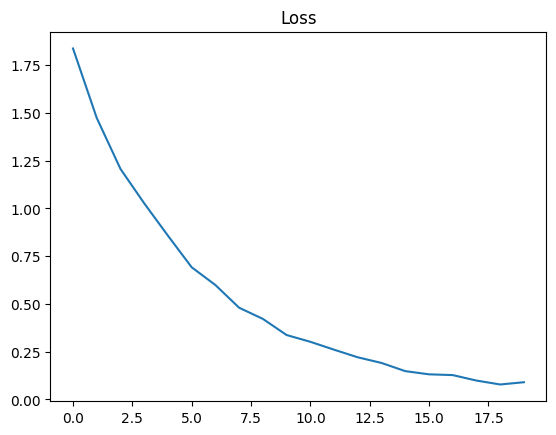

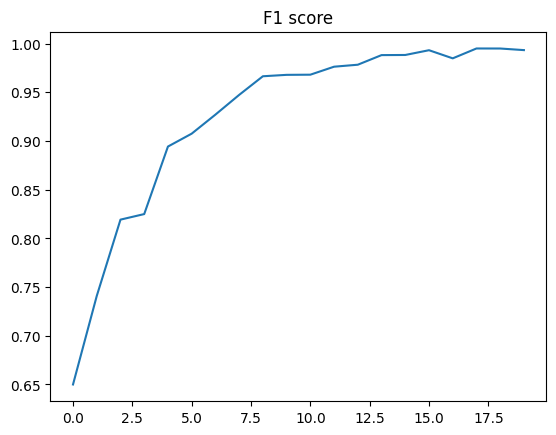

In [ ]:
num_epochs = 20
loss_list = []
f1_list = []

for epoch in range(num_epochs):
    # Training
    model.train()
    model.to(device)
    for batch in dataloader_train:
        data = batch['data'].to(device)
        targets = batch['target'].to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    model.to('cpu')
    with torch.no_grad():
        for batch in dataloader_eval:
            data = batch['data']
            targets = batch['target']
            # Compute cross-entropy loss
            logits = model(data)
            loss = loss_fn(logits, targets)
            loss_list.append(loss.item())
            # Compute f1 score
            targets_pred = torch.argmax(logits, dim = 1)
            f1 = f1_score(targets, targets_pred, average = 'macro')
            f1_list.append(f1)

plt.plot(loss_list)
plt.title('Loss')
plt.show()

plt.plot(f1_list)
plt.title('F1 score')
plt.show()

**Do testing**

In [ ]:
model.eval()
with torch.no_grad():
    for batch in dataloader_test:
        data = batch['data']
        targets = batch['target']
        # Compute f1 score
        logits = model(data)
        targets_pred = torch.argmax(logits, dim = 1)
        f1 = f1_score(targets, targets_pred, average = 'macro')
        print(f'F1 score: {f1}')

F1 score: 0.8716749614864614


**Save the model**

In [ ]:
path = 'my_model_MNIST.pth'
torch.save(model, path)

**Copyright  Beaver-Edge AI Institute. All Rights Reserved. No part of this document may be copied or reproduced without the written permission of Beaver-Edge AI Institute.**